/Users/fangsiyu/dev-env/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 30446 (\N{CJK UNIFIED IDEOGRAPH-76EE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/Users/fangsiyu/dev-env/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 27161 (\N{CJK UNIFIED IDEOGRAPH-6A19}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/Users/fangsiyu/dev-env/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 32218 (\N{CJK UNIFIED IDEOGRAPH-7DDA}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/Users/fangsiyu/dev-env/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 24615 (\N{CJK UNIFIED IDEOGRAPH-6027}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/Users/fangsiyu/dev-env/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 36852 (\N{CJK UNIFIE

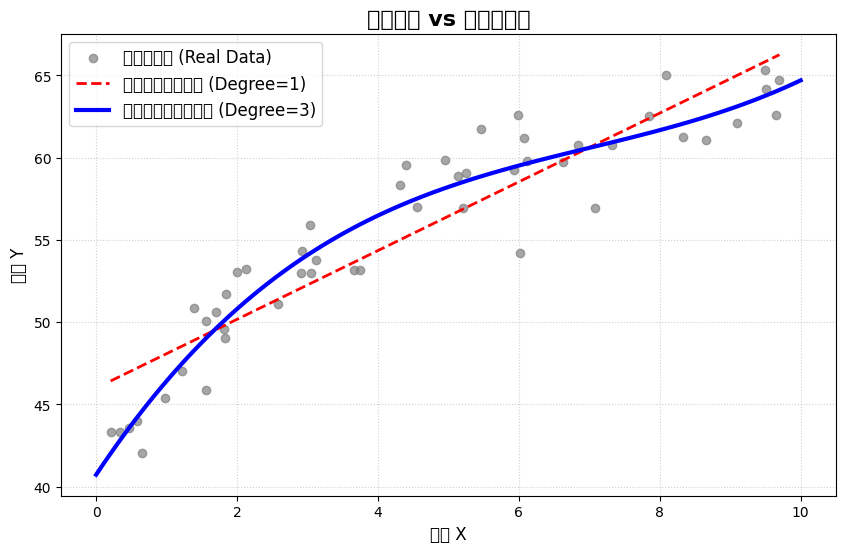

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures

# ==========================================
# 1. 準備模擬資料 (假設 X 是財富, Y 是壽命)
# ==========================================
np.random.seed(42) # 固定亂數種子，讓你每次跑的圖都長一樣
# 產生 50 個 0 到 10 之間的 X
X = np.sort(np.random.rand(50, 1) * 10, axis=0) 
# 創造一個非線性的「對數曲線」關係，並加入一點上下波動的雜訊
y = 40 + 10 * np.log1p(X).ravel() + np.random.randn(50) * 2

# ==========================================
# 2. 訓練模型一：簡單線性迴歸 (對應教授的 m1)
# ==========================================
model_linear = LinearRegression()
model_linear.fit(X, y) # 直接拿原本的 X 去訓練
y_pred_linear = model_linear.predict(X)

# ==========================================
# 3. 訓練模型二：多項式迴歸 (對應教授的 m3)
# ==========================================
# 【作弊招式啟動】：幫變數 X 產生 2次方、3次方的「影分身」
poly_features = PolynomialFeatures(degree=3, include_bias=False)
X_poly = poly_features.fit_transform(X) # X_poly 現在包含了 [X, X^2, X^3]

# 注意看！我們依然是用一模一樣的 LinearRegression()！
# 電腦根本不知道它在畫曲線，它以為它只是在做「3個變數的多元迴歸」
model_poly = LinearRegression()
model_poly.fit(X_poly, y) 

# ==========================================
# 4. 畫圖對決！
# ==========================================
plt.figure(figsize=(10, 6))

# 畫出真實資料點 (散佈圖)
plt.scatter(X, y, color='gray', label='真實資料點 (Real Data)', alpha=0.7)

# 畫出模型一：死板的直線 (紅色虛線)
plt.plot(X, y_pred_linear, color='red', linestyle='--', linewidth=2, 
         label='模型一：直線預測 (Degree=1)')

# 畫出模型二：會轉彎的曲線 (藍色實線)
# 為了讓畫出來的曲線平滑，我們產生 100 個密集的點來畫線
X_smooth = np.linspace(0, 10, 100).reshape(-1, 1)
X_smooth_poly = poly_features.transform(X_smooth) # 密集的點也要變身成 3 次方
y_smooth_poly = model_poly.predict(X_smooth_poly)
plt.plot(X_smooth, y_smooth_poly, color='blue', linewidth=3, 
         label='模型二：多項式預測 (Degree=3)')

# 設定圖片的標題與樣式
plt.title('線性迴歸 vs 多項式迴歸', fontsize=16, fontweight='bold')
plt.xlabel('變數 X', fontsize=12)
plt.ylabel('目標 Y', fontsize=12)
plt.legend(fontsize=12)
plt.grid(True, linestyle=':', alpha=0.6)


plt.show()

In [2]:
import pandas as pd
import numpy as np
import statsmodels.formula.api as smf

# 假設我們把剛才產生的 X 和 y 放進 DataFrame 裡
df = pd.DataFrame({'X': X.flatten(), 'y': y})

# ==========================================
# 對應教授投影片 m3 的寫法：加入 2次方 和 3次方
# ==========================================
# R 語言寫法：lm(y ~ X + I(X^2) + I(X^3))
# Python statsmodels 寫法：
model_poly_sm = smf.ols('y ~ X + np.power(X, 2) + np.power(X, 3)', data=df).fit()

# 印出你最熟悉的統計報表！
print(model_poly_sm.summary())

                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.924
Model:                            OLS   Adj. R-squared:                  0.919
Method:                 Least Squares   F-statistic:                     186.2
Date:                Wed, 29 Apr 2026   Prob (F-statistic):           9.91e-26
Time:                        13:29:00   Log-Likelihood:                -99.992
No. Observations:                  50   AIC:                             208.0
Df Residuals:                      46   BIC:                             215.6
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                     coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------
Intercept         40.7302      1.046     38.